In [159]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.special import jv

In [160]:
lambd = 3.5 / 100
D = 1.1
f = 0.45

k = (2 * math.pi) / lambd
R0 = D / 2
p = 2 * f
v = 3.5 * (R0 / p)

In [161]:
FH = []
steps = []
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

FE = []
max_x_FE = []
max_y_FE = []
min_x_FE = []
min_y_FE = []

In [162]:
for teta in np.arange(-np.pi / 2, np.pi / 2, 0.00001):
    u = k * R0 * np.sin(teta)

    fe = np.cos(teta / 2) ** 2 * (0.74 * ((v * jv(1, v) * jv(0, u) - u * jv(1, u) * jv(0, v)) / (v ** 2 - u ** 2)) + (0.26 * jv(1, u) / u) + (0.25 * (u * jv(1, u) * jv(2, 1.5 * v) - 1.5 * v * jv(1, 1.5 * v) * jv(2, u)) / ((1.5 * v) ** 2 - u ** 2))) * 1 / (0.74 * (jv(1, v) / v) + 0.13)
    
    fh = np.cos(teta / 2) ** 2 * (0.74 * ((v * jv(1, v) * jv(0, u) - u * jv(1, u) * jv(0, v)) / (v ** 2 - u ** 2)) + (0.26 * jv(1, u) / u) - (0.25 * (u * jv(1, u) * jv(2, 1.5 * v) - 1.5 * v * jv(1, 1.5 * v) * jv(2, u)) / ((1.5 * v) ** 2 - u ** 2))) * 1 / (0.74 * (jv(1, v) / v) + 0.13)

    FE.append(fe)
    FH.append(fh)

    steps.append(math.degrees(teta))


for i in range(1, len(FH) - 1):
    if FH[i] < FH[i - 1] and FH[i] < FH[i + 1]:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FE) - 1):
    if FE[i] < FE[i - 1] and FE[i] < FE[i + 1]:
        min_x_FE.append(steps[i])
        min_y_FE.append(0)

for i in range(1, len(FE) - 1):
    if FE[i] > FE[i - 1] and FE[i] > FE[i + 1]:
        max_x_FE.append(steps[i])
        max_y_FE.append(FE[i])

for i in range(1, len(FH) - 1):
    if 0.707 < FH[i] < 0.708:
        y707 = FH[i]
        x707 = steps[i]

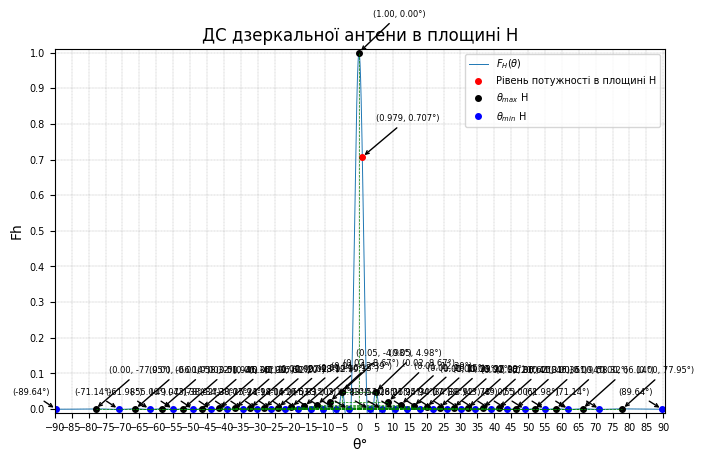

In [163]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС дзеркальної антени в площині H")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")
ax.plot(x707, y707, 'ro', markersize=4, label="Рівень потужності в площині H")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('Fh', fontsize=10)
plt.xticks(np.arange(-100, 100, 5), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(-90.05, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині Н, лабораторна 6.jpg", dpi=600)
plt.show()

In [164]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |-89.64|  0  |
| 2 |-71.14|  0  |
| 3 |-61.98|  0  |
| 4 |-55.00|  0  |
| 5 |-49.07|  0  |
| 6 |-43.78|  0  |
| 7 |-38.92|  0  |
| 8 |-34.38|  0  |
| 9 |-30.07|  0  |
| 10 |-25.94|  0  |
| 11 |-21.94|  0  |
| 12 |-18.06|  0  |
| 13 |-14.26|  0  |
| 14 |-10.53|  0  |
| 15 |-6.83|  0  |
| 16 |-3.10|  0  |
| 17 |3.10|  0  |
| 18 |6.83|  0  |
| 19 |10.53|  0  |
| 20 |14.26|  0  |
| 21 |18.06|  0  |
| 22 |21.94|  0  |
| 23 |25.94|  0  |
| 24 |30.07|  0  |
| 25 |34.38|  0  |
| 26 |38.92|  0  |
| 27 |43.78|  0  |
| 28 |49.07|  0  |
| 29 |55.00|  0  |
| 30 |61.98|  0  |
| 31 |71.14|  0  |
| 32 |89.64|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |-77.95| 0.00|
| 2 |-66.14| 0.00|
| 3 |-58.32| 0.00|
| 4 |-51.94| 0.00|
| 5 |-46.36| 0.00|
| 6 |-41.31| 0.00|
| 7 |-36.62| 0.00|
| 8 |-32.20| 0.00|
| 9 |-27.98| 0.00|
| 10 |-23.92| 0.00|
| 11 |-19.99| 0.01|
| 12 |-16.15| 0.

In [165]:
for i in range(1, len(FE) - 1):
    if 0.707 < FE[i] < 0.708:
        y707 = FE[i]
        x707 = steps[i]

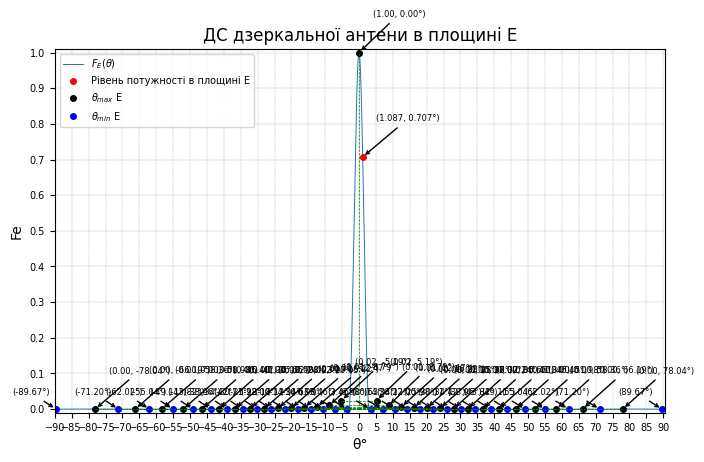

In [166]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС дзеркальної антени в площині E")
ax.plot(steps, FE, linewidth=0.7, label="$ F_{E}(θ) $")
ax.plot(x707, y707, 'ro', markersize=4, label="Рівень потужності в площині E")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
ax.plot(max_x_FE, max_y_FE, "o", markersize=4, color="black", label="$ \\theta_{max} $ E")
ax.plot(min_x_FE, min_y_FE, "o", markersize=4, color="blue", label="$ \\theta_{min} $ E")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('Fe', fontsize=10)
plt.xticks(np.arange(-100, 100, 5), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(-90.05, 90.5)


for i in range(len(max_x_FE)):
    plt.vlines(x=max_x_FE[i], ymin=0, ymax=max_y_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FE[i], xmin=0, xmax=max_x_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FE[i]:.2f}, {max_x_FE[i]:.2f}\u00b0)',
                 xy=(max_x_FE[i], max_y_FE[i]),
                 xytext=(max_x_FE[i]+4, max_y_FE[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FE)):
    plt.annotate(f'({min_x_FE[i]:.2f}\u00b0)',
                 xy=(min_x_FE[i], min_y_FE[i]),
                 xytext=(min_x_FE[i]-13, min_y_FE[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper left", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині E, лабораторна 6.jpg", dpi=600)
plt.show()

In [167]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FE:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FE:
    print(f"| {m} |{i:.2f}| {max_y_FE[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |-89.67|  0  |
| 2 |-71.20|  0  |
| 3 |-62.02|  0  |
| 4 |-55.04|  0  |
| 5 |-49.11|  0  |
| 6 |-43.82|  0  |
| 7 |-38.96|  0  |
| 8 |-34.42|  0  |
| 9 |-30.11|  0  |
| 10 |-25.98|  0  |
| 11 |-22.00|  0  |
| 12 |-18.12|  0  |
| 13 |-14.34|  0  |
| 14 |-10.63|  0  |
| 15 |-6.98|  0  |
| 16 |-3.46|  0  |
| 17 |3.46|  0  |
| 18 |6.98|  0  |
| 19 |10.63|  0  |
| 20 |14.34|  0  |
| 21 |18.12|  0  |
| 22 |22.00|  0  |
| 23 |25.98|  0  |
| 24 |30.11|  0  |
| 25 |34.42|  0  |
| 26 |38.96|  0  |
| 27 |43.82|  0  |
| 28 |49.11|  0  |
| 29 |55.04|  0  |
| 30 |62.02|  0  |
| 31 |71.20|  0  |
| 32 |89.67|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |-78.04| 0.00|
| 2 |-66.19| 0.00|
| 3 |-58.36| 0.00|
| 4 |-51.98| 0.00|
| 5 |-46.40| 0.00|
| 6 |-41.34| 0.00|
| 7 |-36.65| 0.00|
| 8 |-32.24| 0.00|
| 9 |-28.02| 0.00|
| 10 |-23.97| 0.00|
| 11 |-20.05| 0.00|
| 12 |-16.22| 0.